In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from platypus import NSGAII, Problem, Real, Integer, SBX, PM, CompoundOperator

## Initialize reservoirs

In [30]:
from Reservoir4 import Reservoir

ice_harbor = Reservoir(SA=9200*4047,capacity=603000,tail_elev=339,pool_elev=446,bottom_elev=310,pc=106_000, spillway_cap=850_000, alfa=2.2, beta=4.9)
lower_monumental = Reservoir(SA=6590*4047,capacity=810000,tail_elev=439,pool_elev=548.3,bottom_elev=406,pc=130_000, spillway_cap=850_000, alfa=2.2, beta=4.9)
little_goose = Reservoir(SA=10025*4047,capacity=903000,tail_elev=539,pool_elev=646.5,bottom_elev=500,pc=130_000, spillway_cap=850_000, alfa=2.2, beta=4.9)
lower_granite = Reservoir(SA=8900*4047,capacity=810000,tail_elev=636,pool_elev=746.5,bottom_elev=590,pc=130_000, spillway_cap=850_000, alfa=2.2, beta=4.9)

## Import data

In [3]:
# we only need lower granite inflow and tributary flow for each reservoir. Importing outflow data for comparison.
pre_cutoff = datetime(1970,1,1)
post_cutoff = datetime(1993,1,1)

# lower granite
lower_granite_data = pd.read_csv('lowergraniteinflow.csv')
lower_granite_outflows = pd.read_csv('lowergraniteoutflow.csv')
lower_granite_data = lower_granite_data.merge(lower_granite_outflows, how='inner', on=['date'])
lower_granite_data['date'] = pd.to_datetime(lower_granite_data['date'])
lower_granite_data['L (unit:cfs)'] = 0 #NO TRIB DATA FOR LOWER GRANITE
lower_granite_pre = lower_granite_data[lower_granite_data['date'] <= pre_cutoff]
lower_granite_post = lower_granite_data[lower_granite_data['date'] >= post_cutoff]

# little goose
little_goose_data = pd.read_csv('littlegooseoutflow.csv')               
little_goose_data['L (unit:cfs)'] = 0 #NO TRIB DATA FOR LITTLE GOOSE
little_goose_data['date'] = pd.to_datetime(little_goose_data['date'])
little_goose_pre = little_goose_data[little_goose_data['date'] <= pre_cutoff]
little_goose_post = little_goose_data[little_goose_data['date'] >= post_cutoff]

# lower monumental
lower_monumental_trib = pd.read_csv('lowermontrib.csv')
lower_monumental_outflows = pd.read_csv('lowermonumentaloutflow.csv')
lower_monumental_trib['L (unit:cfs)'] = lower_monumental_trib['L (unit:cfs)'].clip(lower=0)
lower_monumental_data = lower_monumental_trib.merge(lower_monumental_outflows, how='inner', on=['date'])
lower_monumental_data['date'] = pd.to_datetime(lower_monumental_data['date'])
lower_monumental_pre = lower_monumental_data[lower_monumental_data['date'] <= pre_cutoff]
lower_monumental_post = lower_monumental_data[lower_monumental_data['date'] >= post_cutoff]

# ice harbor
ice_harbor_outflow = pd.read_csv('iceharboroutflow.csv')
ice_harbor_trib = pd.read_csv('iceharbortrib.csv')
ice_harbor_outflows = pd.read_csv('iceharboroutflow.csv')
ice_harbor_trib['L (unit:cfs)'] = ice_harbor_trib['L (unit:cfs)'].clip(lower=0)
ice_harbor_data = ice_harbor_trib.merge(ice_harbor_outflows, how='inner', on=['date'])
ice_harbor_data['date'] = pd.to_datetime(ice_harbor_data['date'])
ice_harbor_pre = ice_harbor_data[ice_harbor_data['date'] <= pre_cutoff]
ice_harbor_post = ice_harbor_data[ice_harbor_data['date'] >= post_cutoff]

## Test simulation: simulate reservoirs in series

In [4]:
# lower granite simulation post 1993
keep_LGR=1
initial_height_LGR = 670*0.3046
param_LGR = {'mef':50000*(0.3046**3), 'h1':710*0.3046, 'm':1000}
datetimes=lower_granite_post['date']
prev_out_LGR=lower_granite_post['A (unit:cfs)'].values*0.3046**3
tributary_LGR=lower_granite_post['L (unit:cfs)'].values*0.3046**3
    
LGR_outflow, LGR_hydro, LGR_height = lower_granite.simulate(keep_LGR, initial_height_LGR, param_LGR, datetime=datetimes, prev_out=prev_out_LGR, tributary=tributary_LGR)

# little goose simulation
keep_LGS=1
initial_height_LGS = 570*0.3046
param_LGS = {'mef':60000*(0.3046**3), 'h1':760*0.3046, 'm':1000}
datetimes=little_goose_post['date']
prev_out_LGS=LGR_outflow
tributary_LGS=little_goose_post['L (unit:cfs)'].values*0.3046**3

LGS_outflow, LGS_hydro, LGS_height = little_goose.simulate(keep_LGS, initial_height_LGS, param_LGS, datetime=datetimes, prev_out=prev_out_LGS, tributary=tributary_LGS)

# lower monumental simulation
keep_LMN=1
initial_height_LMN = 470*0.3046
param_LMN = {'mef':70000*(0.3046**3), 'h1':810*0.3046, 'm':1000}
datetimes=lower_monumental_post['date']
prev_out_LMN=LGS_outflow
tributary_LMN=lower_monumental_post['L (unit:cfs)'].values*0.3046**3

LMN_outflow, LMN_hydro, LMN_height = lower_monumental.simulate(keep_LMN, initial_height_LMN, param_LMN, datetime=datetimes, prev_out=prev_out_LMN, tributary=tributary_LMN)

# ice harbor simulation
keep_ICH=1
initial_height_ICH = 370*0.3046
param_ICH = {'mef':80000*(0.3046**3), 'h1':600*0.3046, 'm':1000}
datetimes=ice_harbor_post['date']
prev_out_ICH=LMN_outflow
tributary_ICH=ice_harbor_post['L (unit:cfs)'].values*0.3046**3  

ICH_outflow, ICH_hydro, ICH_height = ice_harbor.simulate(keep_ICH, initial_height_ICH, param_ICH, datetime=datetimes, prev_out=prev_out_ICH, tributary=tributary_ICH)

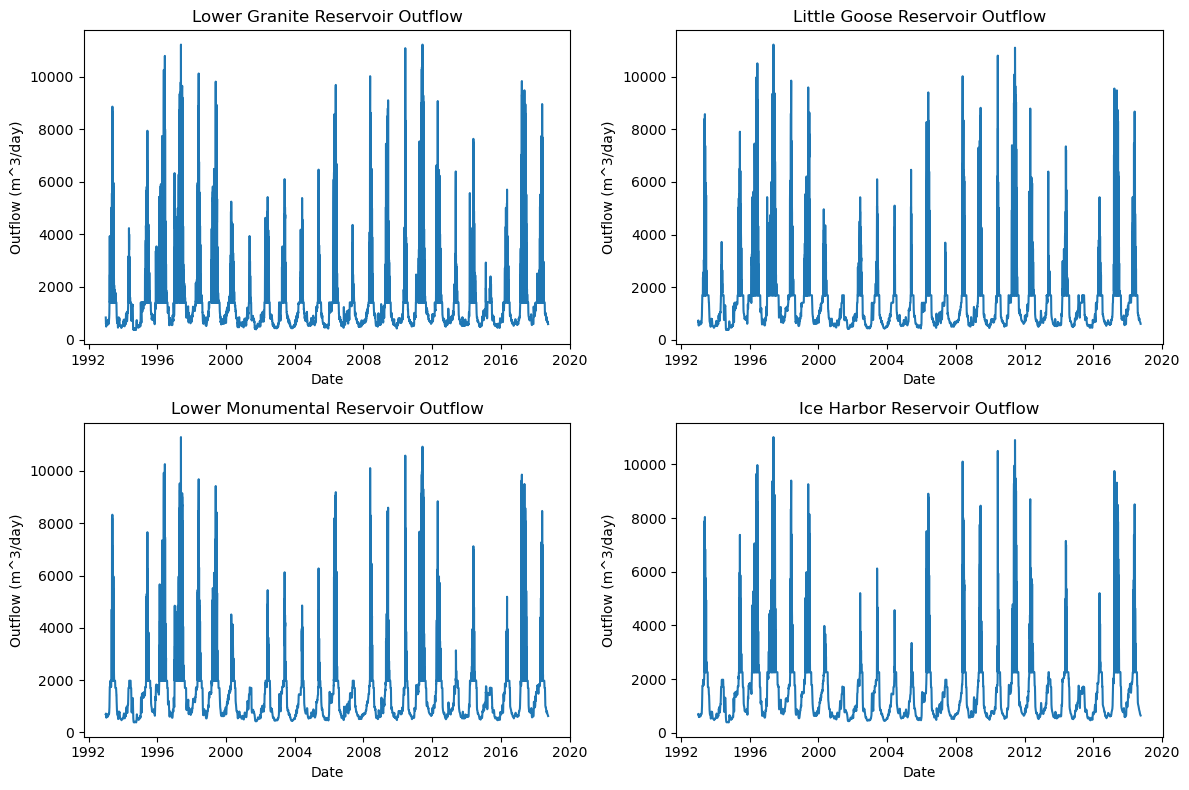

In [5]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.plot(datetimes, LGR_outflow)
plt.xlabel('Date')
plt.ylabel('Outflow (m^3/day)')
plt.title('Lower Granite Reservoir Outflow')

plt.subplot(2,2,2)
plt.plot(datetimes, LGS_outflow)
plt.xlabel('Date')
plt.ylabel('Outflow (m^3/day)')
plt.title('Little Goose Reservoir Outflow')

plt.subplot(2,2,3)
plt.plot(datetimes, LMN_outflow)
plt.xlabel('Date')
plt.ylabel('Outflow (m^3/day)')
plt.title('Lower Monumental Reservoir Outflow')

plt.subplot(2,2,4)
plt.plot(datetimes, ICH_outflow)
plt.xlabel('Date')
plt.ylabel('Outflow (m^3/day)')
plt.title('Ice Harbor Reservoir Outflow')

plt.tight_layout()

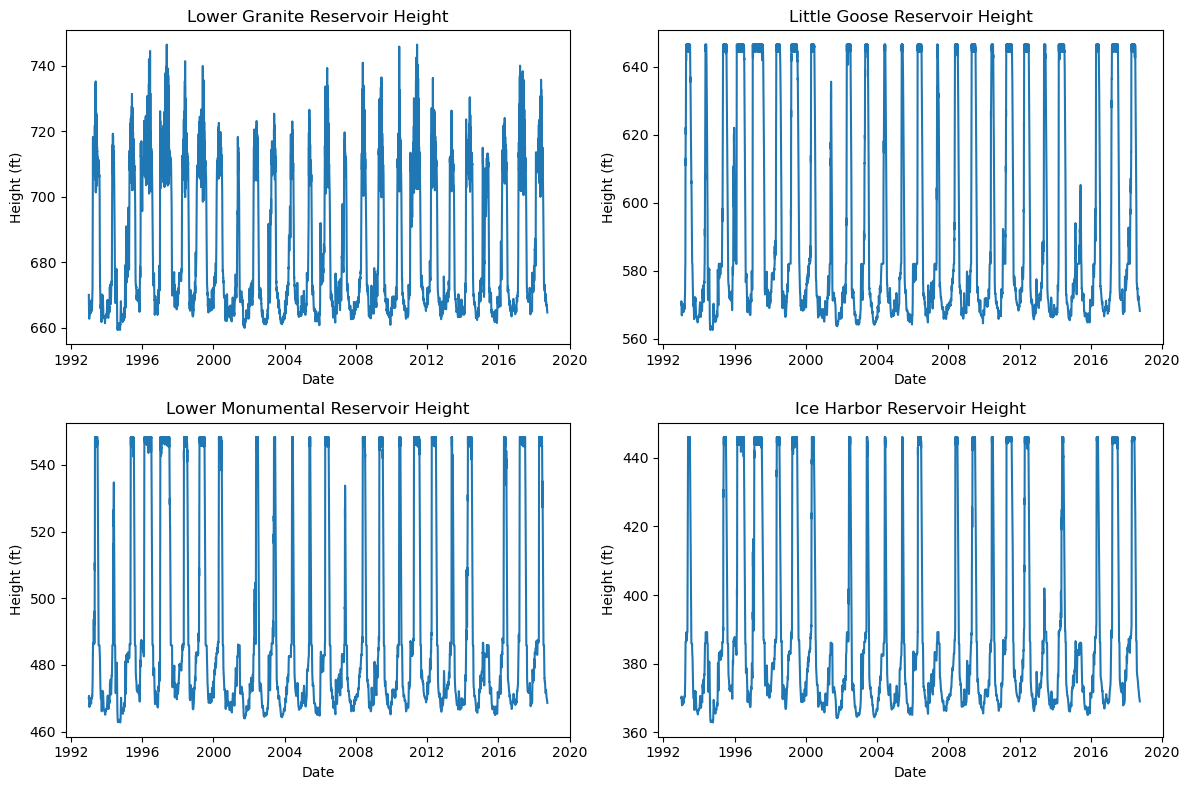

In [6]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.plot(datetimes, LGR_height/0.3046)
plt.xlabel('Date')
plt.ylabel('Height (ft)')
plt.title('Lower Granite Reservoir Height')

plt.subplot(2,2,2)
plt.plot(datetimes, LGS_height/0.3046)
plt.xlabel('Date')
plt.ylabel('Height (ft)')
plt.title('Little Goose Reservoir Height')
    
plt.subplot(2,2,3)
plt.plot(datetimes, LMN_height/0.3046)
plt.xlabel('Date')
plt.ylabel('Height (ft)')
plt.title('Lower Monumental Reservoir Height')

plt.subplot(2,2,4)
plt.plot(datetimes, ICH_height/0.3046)
plt.xlabel('Date')
plt.ylabel('Height (ft)')
plt.title('Ice Harbor Reservoir Height')

plt.tight_layout()

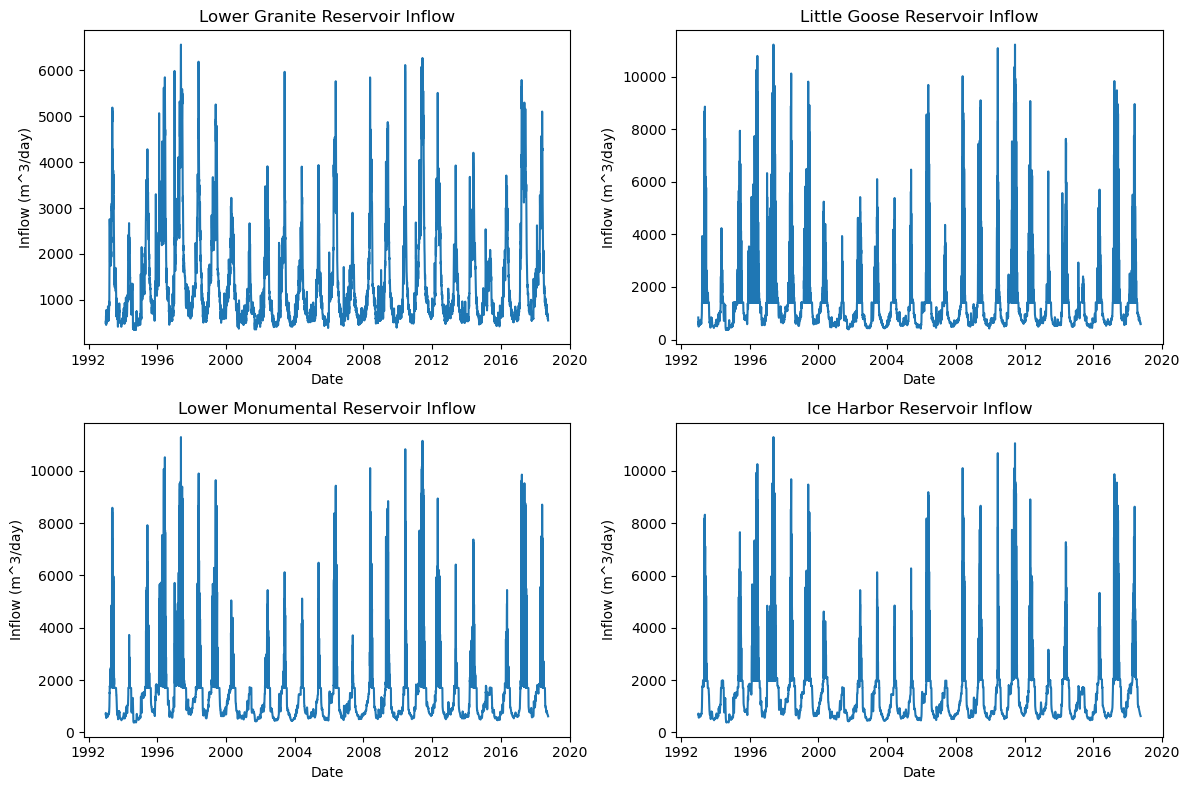

In [7]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.plot(datetimes, prev_out_LGR + tributary_LGR)
plt.xlabel('Date')
plt.ylabel('Inflow (m^3/day)')
plt.title('Lower Granite Reservoir Inflow')

plt.subplot(2,2,2)
plt.plot(datetimes, prev_out_LGS + tributary_LGS)
plt.xlabel('Date')
plt.ylabel('Inflow (m^3/day)')
plt.title('Little Goose Reservoir Inflow')
    
plt.subplot(2,2,3)
plt.plot(datetimes, prev_out_LMN + tributary_LMN)
plt.xlabel('Date')
plt.ylabel('Inflow (m^3/day)')
plt.title('Lower Monumental Reservoir Inflow')

plt.subplot(2,2,4)
plt.plot(datetimes, prev_out_ICH + tributary_ICH)
plt.xlabel('Date')
plt.ylabel('Inflow (m^3/day)')
plt.title('Ice Harbor Reservoir Inflow')

plt.tight_layout()

## Calculate new objective function

In [8]:
# objective function: minimize number of years where minimum reservoir outflow is below historical minimum outflow median

hist_min_LGR = np.median(lower_granite_pre.groupby(lower_granite_pre['date'].dt.year)['H (unit:cfs)'].min()) * 0.3046**3
hist_min_LGS = np.median(little_goose_pre.groupby(little_goose_pre['date'].dt.year)['H (unit:cfs)'].min()) * 0.3046**3
hist_min_LMN = np.median(lower_monumental_pre.groupby(lower_monumental_pre['date'].dt.year)['H (unit:cfs)'].min()) * 0.3046**3
hist_min_ICH = np.median(ice_harbor_pre.groupby(ice_harbor_pre['date'].dt.year)['H (unit:cfs)'].min()) * 0.3046**3

def calculate_objective(LGR_outflow, LGS_outflow, LMN_outflow, ICH_outflow, datetimes):
    df = pd.DataFrame({'date': datetimes,
                       'LGR_outflow': LGR_outflow,
                       'LGS_outflow': LGS_outflow,
                       'LMN_outflow': LMN_outflow,
                       'ICH_outflow': ICH_outflow})
    df['year'] = df['date'].dt.year

    obj_LGR = df.groupby('year')['LGR_outflow'].min().lt(hist_min_LGR).sum()
    obj_LGS = df.groupby('year')['LGS_outflow'].min().lt(hist_min_LGS).sum()
    obj_LMN = df.groupby('year')['LMN_outflow'].min().lt(hist_min_LMN).sum()
    obj_ICH = df.groupby('year')['ICH_outflow'].min().lt(hist_min_ICH).sum()

    total_objective = (obj_LGR + obj_LGS + obj_LMN + obj_ICH)/(4*len(datetimes)/365)

    return total_objective

num_below_min = calculate_objective(LGR_outflow, LGS_outflow, LMN_outflow, ICH_outflow, datetimes)
print(f'Objective function value: {num_below_min}')

Objective function value: 0.31050616758826033


In [84]:
print((4*len(datetimes)/365))

103.05753424657534


## Optimization time!!

In [9]:
datetimes = lower_granite_post['date']
initial_height_LGR = 670*0.3046
initial_height_LGS = 570*0.3046
initial_height_LMN = 470*0.3046
initial_height_ICH = 370*0.3046
prev_out_LGR = lower_granite_post['A (unit:cfs)'].values*0.3046**3
tributary_LGR = lower_granite_post['L (unit:cfs)'].values*0.3046**3
tributary_LGS = little_goose_post['L (unit:cfs)'].values*0.3046**3
tributary_LMN = lower_monumental_post['L (unit:cfs)'].values*0.3046**3  
tributary_ICH = ice_harbor_post['L (unit:cfs)'].values*0.3046**3

def simulateallopt(params, keep):
    param_LGR = {'mef':params[0], 'h1':params[4], 'm':params[8]}
    param_LGS = {'mef':params[1], 'h1':params[5], 'm':params[9]}
    param_LMN = {'mef':params[2], 'h1':params[6], 'm':params[10]}
    param_ICH = {'mef':params[3], 'h1':params[7], 'm':params[11]}
    keep_LGR = keep[0]
    keep_LGS = keep[1]
    keep_LMN = keep[2]
    keep_ICH = keep[3]
    
    LGR_outflow, LGR_hydro, LGR_height = lower_granite.simulate(keep_LGR, initial_height_LGR, param_LGR, datetime=datetimes, prev_out=prev_out_LGR, tributary=tributary_LGR)
    LGS_outflow, LGS_hydro, LGS_height = little_goose.simulate(keep_LGS, initial_height_LGS, param_LGS, datetime=datetimes, prev_out=LGR_outflow, tributary=tributary_LGS)
    LMN_outflow, LMN_hydro, LMN_height = lower_monumental.simulate(keep_LMN, initial_height_LMN, param_LMN, datetime=datetimes, prev_out=LGS_outflow, tributary=tributary_LMN)
    ICH_outflow, ICH_hydro, ICH_height = ice_harbor.simulate(keep_ICH, initial_height_ICH, param_ICH, datetime=datetimes, prev_out=LMN_outflow, tributary=tributary_ICH)
    
    total_hydro = LGR_hydro + LGS_hydro + LMN_hydro + ICH_hydro
    num_below_min = calculate_objective(LGR_outflow, LGS_outflow, LMN_outflow, ICH_outflow, datetimes)

    return num_below_min, total_hydro

In [75]:
class DamOptimization(Problem):
    def __init__(self):
        # Create a problem with 16 decision variables and 2 objectives
        super(DamOptimization, self).__init__(16, 2)  # 16 decision variables, 2 objectives

        self.types[:] = (
                        [Real(0, 10_000*(0.3046**3))] * 4 + # MEF for all dams, cubic ft -> cubic m
                        [Real(636.1*0.3046, 726.5*0.3046)] + # h1 LGR, ft -> m
                        [Real(539.1*0.3046, 626.5*0.3046)] + # h1 LGS, ft -> m
                        [Real(439.1*0.3046, 528.3*0.3046)] + # h1 LMN, ft -> m
                        [Real(339.1*0.3046, 426.4*0.3046)] + # h1 ICH, ft -> m
                        [Real(500, 5000)] * 4 + # m for all dams
                        [Integer(0,1)] * 4 # keep
                        )

    def evaluate(self, solutions):
        # Check if a single solution is passed
        if not isinstance(solutions, list):
            solutions = [solutions]
        
        for s in solutions:
            # Simulate the lake with current parameters
            params = s.variables[:-4]
            keep = s.variables[-4:]
            
            # Run the simulation function (ensure this is defined)
            num_below_min, total_hydro = simulateallopt(params, keep)
            
            # Set the objectives for the solution
            s.objectives[:] = [num_below_min, -total_hydro]

# Create the problem instance
problem = DamOptimization()

# Set up and run the algorithm
population_size = 50  # Change this to your desired population size
num_generations = 100  # Change this to your desired number of generations
total_evaluations = population_size * num_generations # Calculate total evaluations based on population size and generations
variator = CompoundOperator(
    *[op for _ in range(16) for op in (SBX(), PM())]
)
algorithm = NSGAII(problem,population_size=population_size, variator=variator)
algorithm.run(total_evaluations)  # Run for total evaluations

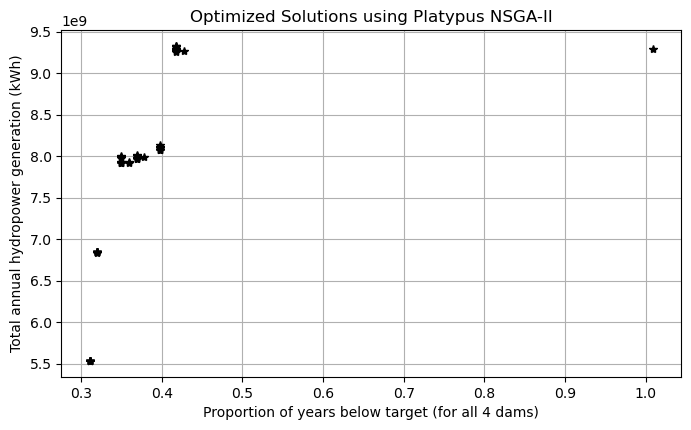

In [107]:
# Extract results for analysis
results = np.array([[s.objectives[0], -s.objectives[1]] for s in algorithm.result])

# Plot results
plt.figure(figsize=(8,4.5))
plt.plot(results[:, 0], results[:, 1], 'k*')
#for i, (x, y) in enumerate(results):
#    plt.text(x, y, str(i), fontsize=8, ha='right', va='bottom')
plt.xlabel('Proportion of years below target (for all 4 dams)')
plt.ylabel('Total annual hydropower generation (kWh)')
plt.title('Optimized Solutions using Platypus NSGA-II')
plt.grid(True)
plt.show()

In [94]:
variables = pd.DataFrame(v for v in algorithm.result[0].variables)
for i in range(len(algorithm.result)):
    variables[i] = [v for v in algorithm.result[i].variables]

results_df = pd.DataFrame(results.T)    

nsga_result = pd.concat([variables, results_df])

display(nsga_result)

nsga_result.to_csv('nsga_result.tsv', sep='\t', index=False)

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,1.535931,51.483674,47.896947,19.297011,24.871175,102.597794,7.45644,196.435618,53.236016,5.58038,...,15.657041,82.798799,12.418166,2.876453,64.712502,55.368222,63.462121,176.83383,52.525858,85.303982
1,10.030481,127.171521,81.118659,88.250481,77.616595,4.811675,25.936638,102.44348,96.908411,86.626475,...,19.567786,173.605225,65.684136,66.775924,90.437568,146.515206,25.179477,102.416437,79.639956,102.909688
2,19.234527,0.386491,0.443483,44.648338,41.438245,11.975075,26.987739,0.230385,9.211826,9.399266,...,36.229252,70.440689,33.497629,63.835477,77.148242,50.997205,2.417082,30.261314,24.139013,46.349249
3,29.057246,200.347995,23.015659,78.638829,100.135309,178.389591,95.490511,213.286843,17.804652,99.334492,...,2.798449,242.709738,29.72713,84.578167,88.199066,188.732612,200.347995,162.268476,19.722743,52.053839
4,196.670357,200.765862,194.251771,197.129293,196.690272,196.885631,196.720012,199.21794,196.498968,197.134213,...,195.69067,198.576383,193.921624,194.934777,196.67881,199.054689,197.694816,199.196593,195.974522,200.307202
5,164.214809,190.797952,165.296542,190.635738,168.513407,190.82879,164.452292,190.80167,165.992272,190.469115,...,169.235843,190.783251,164.863751,190.469115,164.437958,190.14437,190.662822,189.566444,167.243716,165.431879
6,144.430881,160.873691,160.894196,160.300339,160.613438,137.696214,144.430881,160.465889,160.918412,159.910462,...,144.416493,160.649729,160.875527,159.825367,159.750678,160.569145,140.532081,160.580933,144.422493,160.918422
7,104.301511,129.149489,105.103998,105.334979,129.73474,129.661096,105.471313,129.861207,104.972006,109.075466,...,104.527418,129.592455,104.163692,105.429403,129.443499,129.677463,129.336712,129.879612,105.434777,105.403438
8,511.827094,2970.902453,1936.397919,2171.877343,2002.612983,1354.660993,600.113749,4444.229123,1896.951439,2484.495593,...,1068.994972,2369.013948,1105.43994,2196.464073,1899.456783,1815.340083,2636.179402,4224.425087,850.536905,1701.77518
9,502.657886,506.34592,502.413042,516.399478,501.629031,504.004753,510.553015,503.059053,502.65132,503.110087,...,504.037942,532.271052,502.771925,526.668796,889.480783,531.02527,512.721054,500.029488,739.666168,691.82043


In [95]:
# simulate one particular solution
index = 4 # index of solution that we're interested in

# lower granite
keep_LGR=variables.iloc[12,index][0]
initial_height_LGR = 670*0.3046
param_LGR = {'mef':variables.iloc[0,index], 'h1':variables.iloc[4,index], 'm':variables.iloc[8,index]}
datetimes=lower_granite_post['date']
prev_out_LGR=lower_granite_post['A (unit:cfs)'].values*0.3046**3
tributary_LGR=lower_granite_post['L (unit:cfs)'].values*0.3046**3
LGR_outflow, LGR_hydro, LGR_height = lower_granite.simulate(keep_LGR, initial_height_LGR, param_LGR, datetime=datetimes, prev_out=prev_out_LGR, tributary=tributary_LGR)

# little goose simulation
keep_LGS=variables.iloc[13,index][0]
initial_height_LGS = 570*0.3046
param_LGS = {'mef':variables.iloc[1,index], 'h1':variables.iloc[5,index], 'm':variables.iloc[9,index]}
datetimes=little_goose_post['date']
prev_out_LGS=LGR_outflow
tributary_LGS=little_goose_post['L (unit:cfs)'].values*0.3046**3
LGS_outflow, LGS_hydro, LGS_height = little_goose.simulate(keep_LGS, initial_height_LGS, param_LGS, datetime=datetimes, prev_out=prev_out_LGS, tributary=tributary_LGS)

# lower monumental simulation
keep_LMN= variables.iloc[14,index][0]
initial_height_LMN = 470*0.3046
param_LMN = {'mef':variables.iloc[2,index], 'h1':variables.iloc[6,index], 'm':variables.iloc[10,index]}
datetimes=lower_monumental_post['date']
prev_out_LMN=LGS_outflow
tributary_LMN=lower_monumental_post['L (unit:cfs)'].values*0.3046**3
LMN_outflow, LMN_hydro, LMN_height = lower_monumental.simulate(keep_LMN, initial_height_LMN, param_LMN, datetime=datetimes, prev_out=prev_out_LMN, tributary=tributary_LMN)

# ice harbor simulation
keep_ICH= variables.iloc[15,index][0]
initial_height_ICH = 370*0.3046
param_ICH = {'mef':variables.iloc[3,index], 'h1':variables.iloc[7,index], 'm':variables.iloc[11,index]}
datetimes=ice_harbor_post['date']
prev_out_ICH=LMN_outflow
tributary_ICH=ice_harbor_post['L (unit:cfs)'].values*0.3046**3  


ICH_outflow, ICH_hydro, ICH_height = ice_harbor.simulate(keep_ICH, initial_height_ICH, param_ICH, datetime=datetimes, prev_out=prev_out_ICH, tributary=tributary_ICH)


total_hydro = LGR_hydro + LGS_hydro + LMN_hydro + ICH_hydro
num_below_min = calculate_objective(LGR_outflow, LGS_outflow, LMN_outflow, ICH_outflow, datetimes)
if num_below_min < .5 and total_hydro > 6_000_000_000:
    print(i)
    print([keep_LGR,keep_LGS,keep_LMN,keep_ICH,])
    print(f'Total optimized annual hydro (kWh): {total_hydro}')
    print(f'Optimized Objective function value: {num_below_min}')


49
[True, True, True, True]
Total optimized annual hydro (kWh): 8001644640.861214
Optimized Objective function value: 0.34931943853679287


## Run simulation with the best solution

In [108]:
total_hydro = LGR_hydro + LGS_hydro + LMN_hydro + ICH_hydro
num_below_min = calculate_objective(LGR_outflow, LGS_outflow, LMN_outflow, ICH_outflow, datetimes)

print(f'Total optimized annual hydro (kWh): {total_hydro}')
print(f'Optimized Objective function value: {num_below_min}')

Total optimized annual hydro (kWh): 8001644640.861214
Optimized Objective function value: 0.34931943853679287


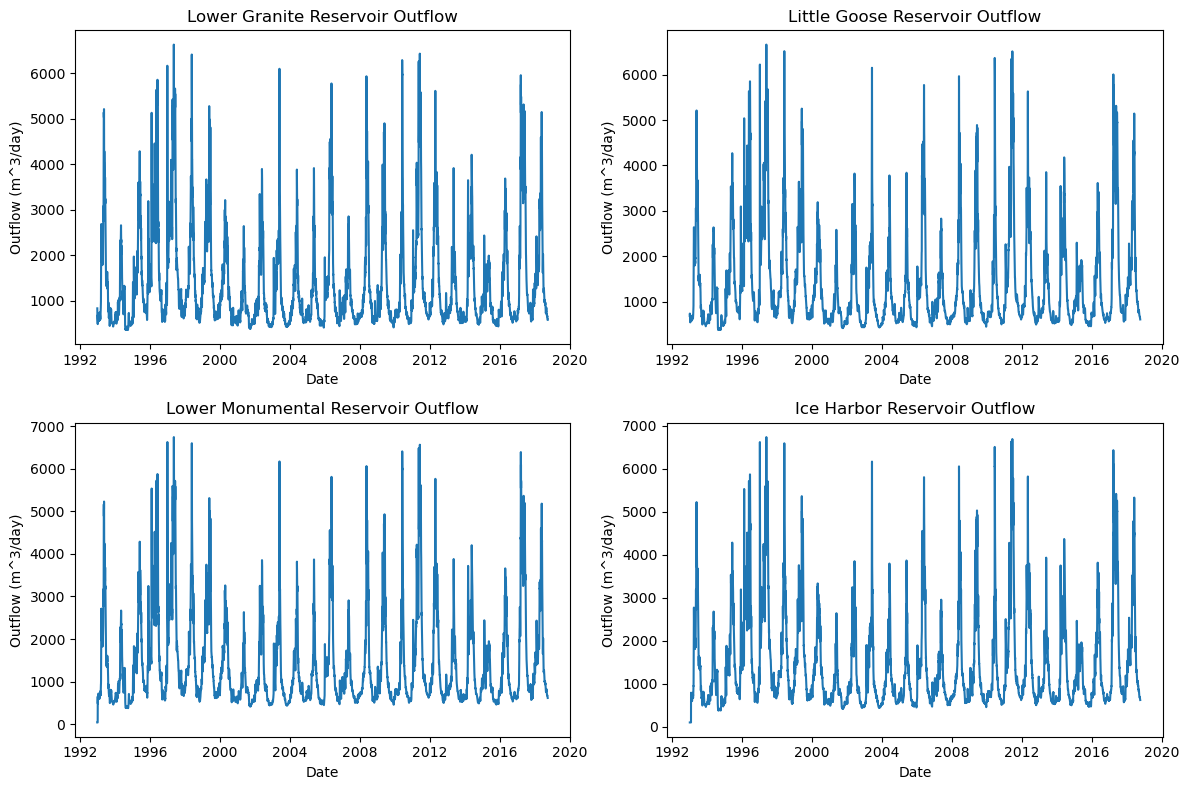

In [109]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.plot(datetimes, LGR_outflow)
plt.xlabel('Date')
plt.ylabel('Outflow (m^3/day)')
plt.title('Lower Granite Reservoir Outflow')

plt.subplot(2,2,2)
plt.plot(datetimes, LGS_outflow)
plt.xlabel('Date')
plt.ylabel('Outflow (m^3/day)')
plt.title('Little Goose Reservoir Outflow')

plt.subplot(2,2,3)
plt.plot(datetimes, LMN_outflow)
plt.xlabel('Date')
plt.ylabel('Outflow (m^3/day)')
plt.title('Lower Monumental Reservoir Outflow')

plt.subplot(2,2,4)
plt.plot(datetimes, ICH_outflow)
plt.xlabel('Date')
plt.ylabel('Outflow (m^3/day)')
plt.title('Ice Harbor Reservoir Outflow')

plt.tight_layout()

/var/folders/g8/67bmljw57jq202ggfmzpdkvm0000gn/T/ipykernel_57439/4264305127.py:10: RuntimeWarning: invalid value encountered in power
  r_test_nat = np.where(h_test > h0, beta * (h_test - h0) ** alfa, 0) # what units??


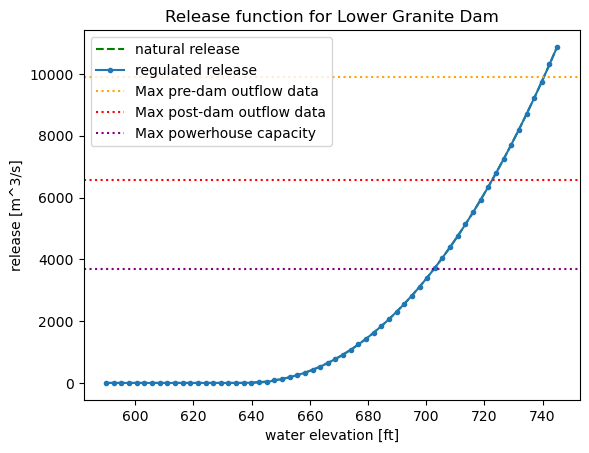

In [100]:
# Define the range of water levels
h_test = np.arange(590*0.3046, 746.5*0.3046, 0.8) # range of heights in ft (converted to m to use in the regulated_release method)

param = param_LGR
beta = 4.9
alfa = 2.2
h0 = lower_granite.tail_elev # in meters

# Calculate the natural release
r_test_nat = np.where(h_test > h0, beta * (h_test - h0) ** alfa, 0) # what units??

# calculate regulated release
r_test_reg = lower_granite.regulated_release(param_LGR, h_test) # m^3/s
#print(param_LGR)

plt.figure()
plt.plot(h_test/0.3046, r_test_nat, 'g--', label='natural release')
plt.plot(h_test/0.3046, r_test_reg, '.-', label='regulated release')
plt.axhline(350_000*0.0283, color='orange', linestyle=':', label='Max pre-dam outflow data')
plt.axhline(231_866*0.0283, color='r', linestyle=':', label='Max post-dam outflow data')
plt.axhline(130_000*0.0283, color='purple', linestyle=':', label='Max powerhouse capacity')
plt.xlabel('water elevation [ft]')
plt.ylabel('release [m^3/s]')
plt.title('Release function for Lower Granite Dam')
plt.legend()

/var/folders/g8/67bmljw57jq202ggfmzpdkvm0000gn/T/ipykernel_57439/2503170545.py:10: RuntimeWarning: invalid value encountered in power
  r_test_nat = np.where(h_test > h0, beta * (h_test - h0) ** alfa, 0)


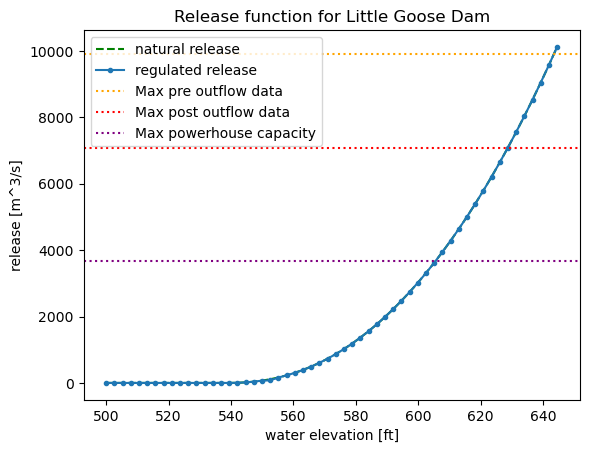

In [103]:
# Define the range of water levels
h_test = np.arange(500*0.3046, 646.5*0.3046, 0.8) # range of heights in ft

param = param_LGS
beta = 4.9
alfa = 2.2
h0 = little_goose.tail_elev # in meters

# Calculate the natural release
r_test_nat = np.where(h_test > h0, beta * (h_test - h0) ** alfa, 0)

# calculate regulated release
r_test_reg = little_goose.regulated_release(param, h_test)

plt.figure()
plt.plot(h_test/0.3046, r_test_nat, 'g--', label='natural release')
plt.plot(h_test/0.3046, r_test_reg, '.-', label='regulated release')
plt.axhline(350_000*0.0283, color='orange', linestyle=':', label='Max pre outflow data')
plt.axhline(250_000*0.0283, color='r', linestyle=':', label='Max post outflow data')
plt.axhline(130_000*0.0283, color='purple', linestyle=':', label='Max powerhouse capacity')
plt.xlabel('water elevation [ft]')
plt.ylabel('release [m^3/s]')
plt.title('Release function for Little Goose Dam')
plt.legend()

/var/folders/g8/67bmljw57jq202ggfmzpdkvm0000gn/T/ipykernel_57439/4150949657.py:10: RuntimeWarning: invalid value encountered in power
  r_test_nat = np.where(h_test > h0, beta * (h_test - h0) ** alfa, 0)


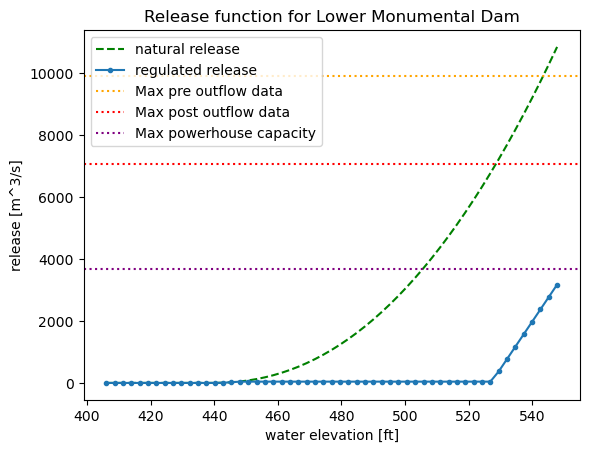

In [104]:
# Define the range of water levels
h_test = np.arange(406*0.3046, 548.3*0.3046, 0.8) # range of heights in ft

param = param_LMN
beta = 4.9
alfa = 2.2
h0 = lower_monumental.tail_elev # in meters

# Calculate the natural release
r_test_nat = np.where(h_test > h0, beta * (h_test - h0) ** alfa, 0)

# calculate regulated release
r_test_reg = lower_monumental.regulated_release(param, h_test)

plt.figure()
plt.plot(h_test/0.3046, r_test_nat, 'g--', label='natural release')
plt.plot(h_test/0.3046, r_test_reg, '.-', label='regulated release')
plt.axhline(350_000*0.0283, color='orange', linestyle=':', label='Max pre outflow data')
plt.axhline(250_000*0.0283, color='r', linestyle=':', label='Max post outflow data')
plt.axhline(130_000*0.0283, color='purple', linestyle=':', label='Max powerhouse capacity')
plt.xlabel('water elevation [ft]')
plt.ylabel('release [m^3/s]')
plt.title('Release function for Lower Monumental Dam')
plt.legend()

/var/folders/g8/67bmljw57jq202ggfmzpdkvm0000gn/T/ipykernel_57439/2681237034.py:10: RuntimeWarning: invalid value encountered in power
  r_test_nat = np.where(h_test > h0, beta * (h_test - h0) ** alfa, 0)


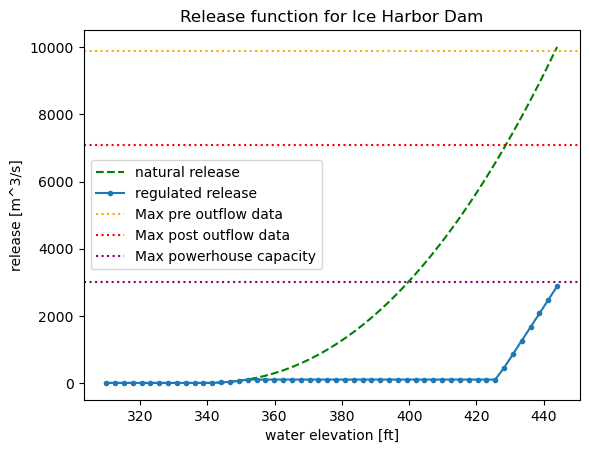

In [105]:
# Define the range of water levels
h_test = np.arange(310*0.3046, 446*0.3046, 0.8) # range of heights in ft

param = param_ICH
beta = 4.9
alfa = 2.2
h0 = ice_harbor.tail_elev # in meters

# Calculate the natural release
r_test_nat = np.where(h_test > h0, beta * (h_test - h0) ** alfa, 0)

# calculate regulated release
r_test_reg = ice_harbor.regulated_release(param, h_test)

plt.figure()
plt.plot(h_test/0.3046, r_test_nat, 'g--', label='natural release')
plt.plot(h_test/0.3046, r_test_reg, '.-', label='regulated release')
plt.axhline(350_000*0.0283, color='orange', linestyle=':', label='Max pre outflow data')
plt.axhline(250_000*0.0283, color='r', linestyle=':', label='Max post outflow data')
plt.axhline(106_000*0.0283, color='purple', linestyle=':', label='Max powerhouse capacity')
plt.xlabel('water elevation [ft]')
plt.ylabel('release [m^3/s]')
plt.title('Release function for Ice Harbor Dam')
plt.legend()